# 0-1 - Exploring the data

Start here. This notebook opens the raw Wikipedia revision data and looks at what is inside, before any model gets involved.

The project studies how large language models classify **potentially manipulative edits** on Wikipedia articles about Armenian and Ukrainian cultural heritage. Before asking a model anything, you need to know your data.

**What you will learn**

- where the data lives, and how the loader finds it
- what one row of the revision table contains (page title, section, comment, diff, and more)
- how much metadata is missing, and why it matters when writing a prompt
- how the edits are spread over articles, and how big they are
- the exact block of text the classifier will send to the model

**Before you start:** install the dependencies once with `pip install -r requirements.txt` and make sure the API key is available (see `README.md`). This notebook does not call any model, so it runs without a key.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Our own helper module. It hides the file paths and the CSV parsing, so the
# notebooks stay short and readable. Look at preprocessing.py, it is short and
# every function is commented.
from preprocessing import (
    available_countries,  # which countries can be loaded, and from where
    load_revisions,       # read a country CSV into a DataFrame
)

# Long edit summaries are cut in the display by default. Raise the limit so we
# can actually read them in the tables below.
pd.set_option('display.max_colwidth', 120)

## 1. Where is the data

Each country has one CSV file, with **one row per Wikipedia edit**. The files are large (about 2.7 GB per country), which is why they are not stored in this git repository. See the README to get them.

`preprocessing.py` looks for them in one of these two places:

1. `data/Ukraine_raw.csv`
2. `data/Ukraine/Ukraine_raw.csv`

Copy the CSV there and it is found automatically, no configuration needed.

The table has these columns:

| column | meaning |
|---|---|
| `page_title` | title of the Wikipedia article |
| `section` | section of the article that was edited |
| `date` | timestamp of the revision |
| `changed_version` | the edit itself, stored as a unified diff |
| `user` | username or IP address of the editor |
| `comment` | the edit summary written by the editor |
| `size` | size of the article after the edit, in bytes |
| `tags` | tags attached by Wikipedia (possible vandalism, mobile edit, ...) |
| `revid`, `parentid` | identifiers of this revision and of the previous one |
| `idx` | row number added by the loader, used to identify an edit in results |

A unified diff looks like this:

```
--- old revision
+++ new revision
@@ -12,7 +12,7 @@
 unchanged context line
-text that was removed
+text that was added
```

Lines starting with `-` were removed, lines starting with `+` were added, and lines starting with a space are context kept for readability.

In [2]:
# available_countries() returns a dictionary: country name -> path of its CSV.
# A value of None means the file was not found, and the message explains
# where the loader looked.
for country, path in available_countries().items():
    print(f'{country}: {path if path else "NOT FOUND"}')

Ukraine: /Users/camilhamdane/CROSS2026/data-extraction-rework/datas/new/Ukraine/Ukraine_raw.csv
Armenia: /Users/camilhamdane/CROSS2026/data-extraction-rework/datas/new/Armenia/Armenia_raw.csv


## 2. Load a random sample

`load_revisions(country, n, seed)` returns `n` edits drawn at random from the whole file.

Two details are worth understanding:

- **Reading the sample is not free.** The loader walks the whole 2.7 GB file once, so expect around 20 seconds per call. Load once at the top of a notebook and reuse the DataFrame.
- **The seed makes the draw reproducible.** With `seed=42` you always get the same edits. This is essential later: comparing two models only makes sense if both see exactly the same sample.

Inside, the loader uses *reservoir sampling*: each edit of the file has the same chance of being picked, and only `n` rows are kept in memory at any time. The implementation is in `_reservoir_sample` if you are curious.

In [6]:
# Load 2000 random Ukrainian edits.
# n=2000 is a good compromise: enough to see patterns, small enough to stay fast.
ukraine = load_revisions('Ukraine', n=2000, seed=42)

print(f'{len(ukraine)} edits loaded')
print(f'columns: {list(ukraine.columns)}')

# head() shows the first rows. The diff column is too long to display, so we
# look at the readable metadata only.
ukraine[['idx', 'page_title', 'section', 'comment']].head(5)

2000 edits loaded
columns: ['idx', 'page_title', 'section', 'date', 'changed_version', 'user', 'comment', 'size', 'tags', 'revid', 'parentid']


,idx,page_title,section,comment
0,831,War in Donbas,,Removed unsourced info. Need [[WP:RS]].
1,1547,Polish–Soviet War,Beginnings of the Polish–Soviet conflict,/* Beginnings of the Polish–Soviet conflict */
2,552,Viktor Yanukovych,Political positions,/* Political positions */ on presidential powers
3,701,Nicholas II,Sainthood,/* Sainthood */
4,416,Eastern Orthodox Church,,Reverted 1 edit by [[Special:Contributions/2604:2000:1480:C777:A55D:AE4C:8224:BE89|2604:2000:1480:C777:A55D:AE4C:822...


## 3. Missing metadata

Many Wikipedia edits have no edit summary, and many have no section. That is normal, but it has one consequence you must know about.

When pandas reads a CSV, an empty cell becomes `NaN` ("not a number"), which is a **float**. In Python, any non-zero float is true, so this test is *always* true:

```python
if comment:            # True even when comment is NaN
    prompt += comment # the prompt now contains the text "nan"
```

That is the classic way to send a nonsense prompt to a model. Two safeguards are in place here:

- the loader turns missing text into an empty string
- the helper `preprocessing.text()` converts any value to a clean string, and is used everywhere a field enters a prompt

In [7]:
# The loader already replaced missing text with an empty string, so here we
# count empty values instead of NaN.
n = len(ukraine)
print(f'without an edit summary: {(ukraine["comment"] == "").sum():5d} / {n}')
print(f'without a section:      {(ukraine["section"] == "").sum():5d} / {n}')
print()

# Sanity check: are there any NaN left in the metadata columns?
# isna() counts missing values per column. The result should be all zeros.
print(ukraine[['page_title', 'section', 'comment']].isna().sum())

without an edit summary:   409 / 2000
without a section:       1227 / 2000

page_title    0
section       0
comment       0
dtype: int64


## 4. Articles, comments and edit size

Three things worth looking at before any classification:

- **Which articles are edited.** A few articles concentrate a lot of activity. This matters for the analysis: results will be dominated by those articles unless you balance them.
- **What editors write.** The edit summary is the editor's own description of the change. It is useful evidence for the model, but it must always be checked against the diff, because a summary saying "fixed typo" can hide a change of meaning.
- **How big the edits are.** The diff is sent to the model, so its size drives the cost and the duration of a run. Most edits are tiny, a handful are huge rewrites, which is why the histogram below uses a logarithmic scale.

In [8]:
# --- Which articles are edited? -----------------------------------------
print(f'{ukraine["page_title"].nunique()} distinct articles, {len(ukraine)} edits')
ukraine['page_title'].value_counts().head(10)

341 distinct articles, 2000 edits


page_title
Joseph Stalin              92
Vladimir Putin             78
Chernobyl disaster         59
Ukraine                    50
Eastern Orthodox Church    45
Nicholas II                40
War in Donbas              39
Russo-Ukrainian war        38
Khazars                    26
Russians                   26
Name: count, dtype: int64

In [9]:
# --- What do editors write in their summary? -----------------------------
# The markup /* section name */ at the start of a summary is added
# automatically by Wikipedia, it is not typed by the editor.
ukraine['comment'].value_counts().head(10)

comment
                                         409
/* External links */                      20
/* History */                             14
/* See also */                             9
/* References */                           6
update                                     5
/* Background */                           4
/* Comparison with other disasters */      3
/* Origin */                               3
/* top */                                  3
Name: count, dtype: int64

In [ ]:
# --- How big are the edits? ---------------------------------------------
# The length of the diff is what drives the cost and the duration of a run.
# pandas computes it in one line, and the column is reused by the plot below.
ukraine['n_chars'] = ukraine['changed_version'].str.len()
ukraine['n_chars'].describe().round(1)

,n_chars,added_lines,removed_lines
count,2000.0,2000.0,2000.0
mean,5502.4,4.8,4.4
std,15273.5,28.0,35.2
min,16.0,0.0,0.0
25%,1088.0,1.0,1.0
50%,2743.0,1.0,1.0
75%,5223.8,2.0,2.0
max,349499.0,683.0,833.0


99 percent of the edits are under 54972 characters, the largest is 349499


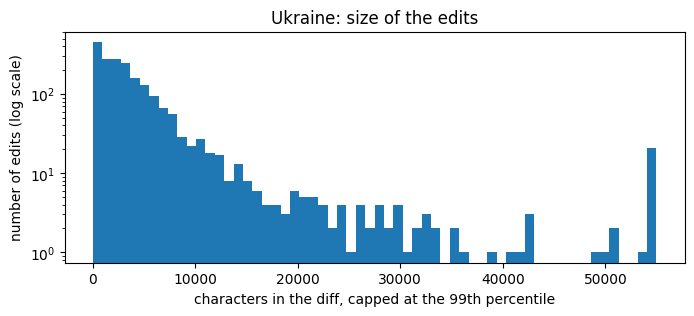

In [12]:
# The distribution of edit sizes. A handful of huge rewrites would flatten
# everything else, so the x axis stops at the 99th percentile and the log
# scale on y keeps the small bars visible.
cutoff = int(ukraine['n_chars'].quantile(0.99))
print(f'99 percent of the edits are under {cutoff} characters, the largest is {ukraine["n_chars"].max()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ukraine['n_chars'].clip(upper=cutoff), bins=60)
ax.set_yscale('log')
ax.set_xlabel('characters in the diff, capped at the 99th percentile')
ax.set_ylabel('number of edits (log scale)')
ax.set_title('Ukraine: size of the edits')
plt.show()

## What next

Ideas to try here before moving on:

- increase `n` in `load_revisions` and see how the numbers change
- pick one article (for example `ukraine[ukraine['page_title'] == 'Kyiv']`) and read its edits in chronological order, to see how a page evolves
- look at the `tags` column: Wikipedia flags some edits, for example with `possible vandalism` or `mw-reverted`
- count how many edits touch a `Talk:` page (`page_title.str.startswith('Talk:')`). Those are editor discussions, not article content, and the classifier treats them differently

Then open `0-2-classification.ipynb`, which sends 10 random Ukrainian edits to a model and reads the labels back.